# Render Skill — Notebook Control

저장된 HDF5에서 RGB 프레임만 꺼내 정적 미디어 생성. 시뮬레이터 안 돎.

- `video(traj, episode)` → MP4 (노트북 inline 재생 가능)
- `preview(traj, n)` → PNG 그리드 (n 에피소드 한 프레임씩)

데이터셋은 프로젝트 내부 `data/datasets/<task>/` 에 있음 (먼저 `/generate` 또는 generate.ipynb 실행).

## Setup

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

TRAJ = (PROJECT_ROOT / 'data' / 'datasets' / 'PickCube-v1'
        / 'trajectory.rgb.pd_joint_pos.physx_cpu.h5')
print('using:', TRAJ.name)
print('exists:', TRAJ.exists())

using: trajectory.rgb.pd_joint_pos.physx_cpu.h5
exists: True


## ① video() — 에피소드 0의 MP4 생성 + 인라인 재생

In [2]:
from scripts.render import video
from IPython.display import Video, display

mp4 = video(TRAJ, episode=0, fps=30)
print('saved:', mp4.name, f'({mp4.stat().st_size / 1024:.1f} KB)')
display(Video(str(mp4), embed=True))

saved: trajectory.rgb.pd_joint_pos.physx_cpu.ep0000.mp4 (58.0 KB)


## ② preview() — 여러 에피소드 중간 프레임 그리드

saved: trajectory.rgb.pd_joint_pos.physx_cpu.preview_mid_3.png


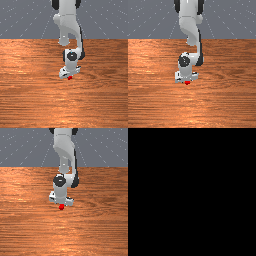

In [3]:
from scripts.render import preview
from IPython.display import Image

png = preview(TRAJ, n=9, frame='mid')
print('saved:', png.name)
display(Image(str(png)))

## ③ Subprocess mode — CLI 동등성 확인

In [4]:
import subprocess, sys as _sys

result = subprocess.run(
    [_sys.executable, str(PROJECT_ROOT / 'scripts' / 'render.py'),
     'preview', '--traj-path', str(TRAJ), '--n', '3', '--frame', 'last'],
    capture_output=True, text=True,
)
print('returncode:', result.returncode)
print(result.stdout.strip())

returncode: 0
render -> C:\Users\hun41\PycharmProjects\maniskill\data\datasets\PickCube-v1\trajectory.rgb.pd_joint_pos.physx_cpu.preview_last_3.png
